I0000 00:00:1780428759.593275 2811713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


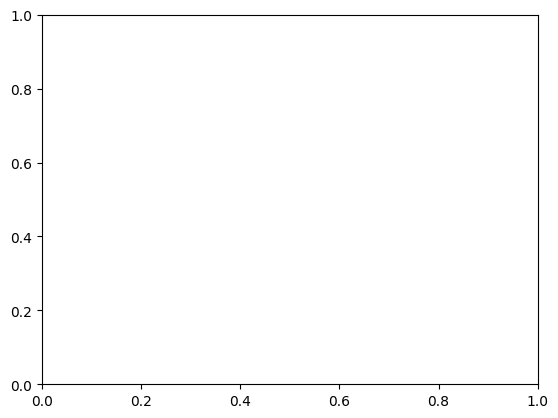

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pylab as plt

import seaborn as sns

from skspatial.objects import Line, Plane
from skspatial.plotting import plot_3d

from skspatial.objects import Line, Cylinder, Point, Points
from skspatial.plotting import plot_3d

import phasespace

import tensorflow

import os

import bisect
import numpy as np
import matplotlib.pylab as plt
import pandas as pd

import seaborn as sns

import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal

import numpy as np
from scipy.interpolate import griddata
from scipy.integrate import quad, trapezoid
from scipy.interpolate import CubicSpline

import matplotlib.pylab as plt
from scipy import stats
from matplotlib import cm
from matplotlib.ticker import LinearLocator

from scipy.interpolate import LinearNDInterpolator

import eloss_tools


import dm_generation_tools as dgt
import detector_simulation_tools as dst
import diagnostics as dg

import glob

import time

####################################
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")


import pickle

In [2]:
#df_decays.columns

In [11]:
#df_decays['M_DM'].unique()

OUTPUT_FILES/generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet
(178019, 46)
masses in file: 
[10000. 20000. 30000. 40000. 50000. 60000. 70000. 80000. 90000.]
mass: 10000
DETECTOR_Y_CONSTRAINED: 20.0
After selections: 8236
Ranges...
None
<class 'NoneType'>
mass: 10000
DETECTOR_Y_CONSTRAINED: 20.0
After selections: 8157
Ranges...
None
<class 'NoneType'>
$M_{DM}$=10000
2


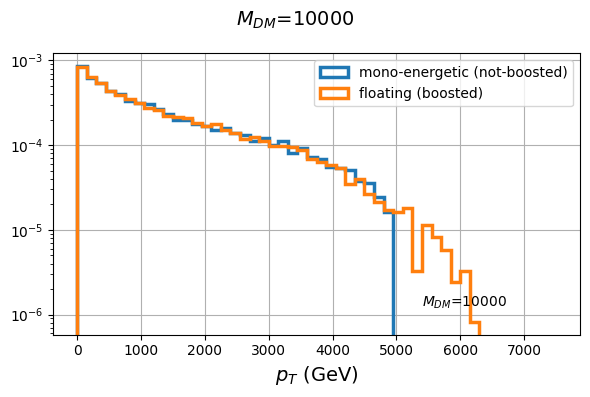

In [34]:
#df_decays = kinematic_diagnostic(masses=[2000])
#df_decays = kinematic_diagnostic(masses=[2000], d=0, r=10, tag='mDM_2000-3000_mA_0.22_dm_model_floating')
#df_decays = kinematic_diagnostic(masses=[2000], d=100, r=10, tag='mDM_2000-3000_mA_0.22_dm_model_core')
#df_decays = kinematic_diagnostic(masses=[2000], d=-7.5, r=458, tag='mDM_2000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')
#df_decays = kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL__COMBINED')

#df_decays = kinematic_diagnostic(masses=[2000], d=-7.5, r=20, tag='mDM_2000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-1000, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_1COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-1000, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_1COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.6, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-1000, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_1COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.6, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-1000, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_1COMBINED')


#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL__COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-1000, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL__COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=458, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=20, tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_COMBINED')
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=20, tag='mDM_7000_mA_0.22_dm_model_core_HIT_DETECTOR_COMBINED')

#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=20, tag='mDM_7000_mA_0.22_dm_model_core_COMBINED')
#infile = 'generated_data_d_-17.5_r_20_mDM_7000_mA_0.22_dm_model_core_COMBINED.parquet'


#tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED'
#tag='mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_002'


#ONLY_TOP_HALF = False
#tag='mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_TRACKER_VOL_COMBINED'
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-17.5, r=1003, input_directory='OUTPUT_FILES', tag=tag, ONLY_TOP_HALF=ONLY_TOP_HALF)
#df_decays = dg.kinematic_diagnostic(masses=[7000], d=-7.5, r=430, input_directory='OUTPUT_FILES', tag=tag, ONLY_TOP_HALF=ONLY_TOP_HALF)

# This tells us what file to read in
#tag='mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_TRACKER_VOL_COMBINED'
#tag='mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED'
#tag='mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_ave_eloss_TRACKER_VOL_COMBINED'

#tag = 'mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_LONG_TRACKER_VOL_V2_COMBINED'
#tag = 'mDM_7000_mA_0.22_dm_model_momentum_constrained__HIT_DETECTOR__ave_eloss__LONG_CMS_COMBINED'
#tag = 'mDM_7000_mA_0.22_dmModel_momentum_constrained__HIT_DETECTOR__ave_eloss_LONG_CMS_COMBINED'

#DETECTOR_Y_CONSTRAINED = 0.0
DETECTOR_Y_CONSTRAINED = 20.0

INNER_DETECTOR_FILTER = False
#INNER_DETECTOR_FILTER = True

#generated_data_depth_-18_diskR_1032_mDM_7000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED.parquet
#tag = 'mDM_7000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED'

'''
tag = 'mDM_7000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_COMBINED'

df_decays = dg.kinematic_diagnostic(masses=[7000], depth=-1000, diskR=6000, input_directory='OUTPUT_FILES', tag=tag, \
                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER)
'''
#generated_data_depth_-8_diskR_459_mDM_1600-10000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED.parquet

#generated_data_depth_-1000.0_diskR_6000_mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet

#tag = 'mDM_7000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR__COMBINED'
#tag = 'mDM_7000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_7000.0_mA_0.22_dmModel_floating_HIT_DETECTOR__COMBINED'
#tag = 'mDM_1600-10000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED'

'''
tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#depth = '-8.0'
#diskR = '459'
#depth = '-108.0'
depth = '-1000.0'
diskR = '6000'
'''

#'''
# Different planes with a range of masses: 1000, 10000, 100000, 500000
tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#depth = '-8.0'
#diskR = '459'
#depth = '-108.0'
depth = '-1000.0'
diskR = '6000'
#'''

'''
# generated_data_depth_-8.0--6000.0_diskR_6000.0_mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet
# Different plans with a range of masses: 1000, 10000, 100000, 500000
# Volume of rock
#tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_core_HIT_DETECTOR_ave_eloss__COMBINED'
tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED'

depth = '-8.0--6000.0'
diskR = '6000.0'
'''


'''
# generated_data_depth_-8.0--6000.0_diskR_6000.0_mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet
# Different plans with a range of masses: 1000, 10000, 100000, 500000
# Volume of rock
#tag = 'mDM_1000.0-9000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'


tag = 'mDM_1000.0-9000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_10000.0-90000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_100000.0-900000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED'

#tag = 'mDM_1000.0-500000.0_mA_0.22_dmModel_core_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_1000.0-9000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED'

depth = '-8.0--4000.0'
diskR = '4000.0'
'''


'''
# generated_data_depth_-8.0--6000.0_diskR_6000.0_mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet
# Different plans with a range of masses: 1000, 10000, 100000, 500000
# Volume of rock
#tag = 'mDM_1000.0-9000.0_mA_0.22_dmModel_core_HIT_DETECTOR_ave_eloss__COMBINED'
tag = 'mDM_10000.0-90000.0_mA_0.22_dmModel_core_HIT_DETECTOR_ave_eloss__COMBINED'

depth = '-8.0--4000.0'
diskR = '40.0'
'''


#tag = 'mDM_7000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_7000.0_mA_0.22_dmModel_core_HIT_DETECTOR_ave_eloss__COMBINED'
#tag = 'mDM_7000.0_mA_0.22_dmModel_core_HIT_DETECTOR__COMBINED'
#depth = '-8.0--3500.0'
#diskR = '3500.0'
#diskR = '40.0'
#depth = '-8.0'
#diskR = '459'
#depth = '-108.0'
#depth = '-1000.0'
#diskR = '6000'


#masses=[1000]
masses =[10000]
#masses = [100000, 200000]
#masses = np.arange(100000,1000000,100000, dtype=int)
#masses = np.arange(10000,100000,10000, dtype=int)
#masses = np.arange(1000,10000,1000, dtype=int)

#df_decays = dg.kinematic_diagnostic(masses=[1000.0], depth=depth, diskR=diskR, input_directory='OUTPUT_FILES', tag=tag, \
#                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER)

import diagnostics as dg

#df_decays = dg.origin_plots(masses=masses, depth=depth, diskR=diskR, input_directory='OUTPUT_FILES', tag=tag, \
#                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER, \
#                           yrange=4000)

#df_decays = dg.detector_hits_plots(masses=masses, depth=depth, diskR=diskR, input_directory='OUTPUT_FILES', tag=tag, \
#                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER, \
#                           xrange=20, zrange=20)


#df_decays = dg.e_and_pt_plots(masses=masses, depth=depth, diskR=diskR, input_directory='OUTPUT_FILES', tag=tag, \
#                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER, \
#                           max_xval=None)

infiles = [\
#'generated_data_depth_-1000.0_diskR_6000_mDM_1000.0-500000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet', \
'generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet', \
'generated_data_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_floating_HIT_DETECTOR_ave_eloss__COMBINED.parquet', \
          
]
    
df_decays = dg.compare_pt_plots(masses=masses, depth=depth, diskR=diskR, input_directory='OUTPUT_FILES', infiles=infiles, \
                                labels=['mono-energetic (not-boosted)', 'floating (boosted)'], \
                                    DETECTOR_Y_CONSTRAINED=DETECTOR_Y_CONSTRAINED, INNER_DETECTOR_FILTER=INNER_DETECTOR_FILTER, \
                           max_xval=None)


print(len(df_decays))

In [36]:
df_decays[0].columns


Index(['M_DM', 'M_A', 'px1', 'py1', 'pz1', 'e1', 'px2', 'py2', 'pz2', 'e2',
       'pmag1', 'pt1', 'eta1', 'theta1', 'phi1', 'pmag2', 'pt2', 'eta2',
       'theta2', 'phi2', 'costh1', 'costh2', 'opening angle', 'hit_detector',
       'hit_inner_detector', 'x0', 'y0', 'z0', 'ip_x0', 'ip_y0', 'ip_z0',
       'ip_x1', 'ip_y1', 'ip_z1', 'ip_inner_x0', 'ip_inner_y0', 'ip_inner_z0',
       'ip_inner_x1', 'ip_inner_y1', 'ip_inner_z1', 'distance_to_detector',
       'efinal_mu1', 'pt1_detector_acceptance',
       'pt1_detector_acceptance_eloss', 'org_nevents', 'total_org_nevents',
       'rho0_origin', 'phi0_origin', 'p_pt_CMS', 'p_phi_CMS', 'p_eta_CMS'],
      dtype='object')

In [30]:
dfhist

NameError: name 'dfhist' is not defined

In [ ]:
#infilename = 'HISTOGRAM_FILES_FOR_RATES/dist_from_depths_at_detector_masses_100000_100000_depth_-8.0--4000.0_diskR_4000.0_mDM_100000.0-900000.0_mA_0.22_dmModel_mom_con_ave_eloss__DETYCON_20.0.png'
#infilename = 'HISTOGRAM_FILES_FOR_RATES/dist_from_depths_at_detector_masses_100000_800000_depth_-8.0--4000.0_diskR_4000.0_mDM_100000.0-900000.0_mA_0.22_dmModel_mom_con_ave_eloss__DETYCON_20.0.png'
#infilename = 'HISTOGRAM_FILES_FOR_RATES/dist_from_depths_at_detector_masses_10000_90000_depth_-8.0--4000.0_diskR_4000.0_mDM_10000.0-90000.0_mA_0.22_dmModel_mom_con_ave_eloss__DETYCON_20.0.png'
infilename = 'HISTOGRAM_FILES_FOR_RATES/dist_from_depths_at_detector_masses_1000_9000_depth_-8.0--4000.0_diskR_4000.0_mDM_1000.0-9000.0_mA_0.22_dmModel_mom_con_ave_eloss__DETYCON_20.0.parquet'


dfhist = pd.read_parquet(infilename)

mass = 4000
bin_start = dfhist[f'{mass} bin_start'].values
count     = dfhist[f'{mass} count'].values
last_bin_width = bin_start[-1] - bin_start[-2]
last_bin_edge = bin_start[-1] + last_bin_width

bs_temp = list(bin_start)
bs_temp.append(last_bin_edge)
bin_edges = np.array(bs_temp)

bin_centers = (np.array(bin_edges[:-1]) + np.array(bin_edges[1:])) / 2

bin_widths = bin_edges[1:] - bin_edges[0:-1]

print(f'{len(count)=}  {len(bin_centers)=}  {len(bin_edges)=} {len(bin_start)=}')

plt.hist(bin_centers, bins=bin_edges, weights=count, edgecolor='black')
plt.xscale('log')

# Check that sum is 1 (or close to it)
print(sum(count*bin_widths))


In [ ]:
dfhist

In [ ]:
list(bin_start).append(last_bin_edge)
bin_edges = np.array(bin_start)

bin_edges

In [ ]:
x0 = df_decays['ip_x0']
y0 = df_decays['ip_y0']
z0 = df_decays['ip_z0']

x1 = df_decays['ip_x1']
y1 = df_decays['ip_y1']
z1 = df_decays['ip_z1']

dx = x0-x1
dy = y0-y1
dz = z0-z1

span = np.sqrt(dx*dx + dy*dy + dz*dz)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(span,bins=100)

plt.subplot(1,2,2)
plt.hist2d(span,df_decays['distance_to_detector'].values ,bins=100)

filter = (df_decays['M_DM'] ==9000)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(span[filter],bins=100)

plt.subplot(1,2,2)
plt.hist2d(span[filter],df_decays['distance_to_detector'][filter].values ,bins=100)

filter = (df_decays['M_DM'] == 9000)
filter = filter & (span>4)# & (span<16)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(span[filter],bins=100)

plt.subplot(1,3,2)
plt.hist2d(span[filter],df_decays['distance_to_detector'][filter].values ,bins=100)

tmp = df_decays['pt1_detector_acceptance_eloss'][filter].values
rescale1 = tmp[tmp>2000]
rescale2 = tmp[tmp<=2000]
print(len(rescale1), len(rescale2))


               
plt.subplot(1,3,3)
#plt.hist(df_decays['pt1_detector_acceptance_eloss'].values ,bins=100, range=(100,7000), histtype='step', density=True)
plt.hist(df_decays['pt1_detector_acceptance_eloss'][filter].values ,bins=100, range=(100,5000), histtype='step', density=True)
plt.yscale('log')

plt.tight_layout()

;

In [ ]:
e1 = df_decays['e1']

px1 = df_decays['px1']
py1 = df_decays['py1']
pz1 = df_decays['pz1']

e2 = df_decays['e2']

px2 = df_decays['px2']
py2 = df_decays['py2']
pz2 = df_decays['pz2']

Apx = px1 + px2
Apy = py1 + py2
Apz = pz1 + pz2
Ae = e1 + e2

Ap, Apt, Aeta, Aphi, Atheta = dst.cartesian_to_cms(Apx, Apy, Apz)

Am = 0.22

Abeta = Ap/Ae


In [ ]:
newtag = f'depth_{depth}_diskR_{diskR}_{tag}'

print(newtag)

In [ ]:
Apt[Apt==Apt]

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(Ap,bins=50, range=(0,7000))
#plt.yscale('log')
plt.xlabel(r"$A'$ $|p|$ (GeV/c)",fontsize=18)

plt.subplot(2,2,2)
plt.hist(Abeta,bins=50, range=(0,1.1))
#plt.yscale('log')
plt.xlabel(r"$A'$ $\beta$",fontsize=18)


plt.subplot(2,2,3)
plt.hist(Apt,bins=50, range=(0,7000))
#plt.yscale('log')
plt.xlabel(r"$A'$ $p_T$ (GeV/c)",fontsize=18)

plt.subplot(2,2,4)
plt.hist(Aeta,bins=50, range=(0,3))
#plt.yscale('log')
plt.xlabel(r"$A'$ $\eta$",fontsize=18)



plt.tight_layout()

outfile = f'dark_photon_A_{newtag}.png'
plt.savefig(outfile)

;

In [ ]:
df_decays.columns

In [ ]:
filter = (df_decays['M_DM'] == 10000)
#filter = filter & (df_decays['distance_to_detector']>100)
#filter = filter & (np.abs(df_decays['eta1']) < 0.1)
#filter = filter & (df_decays['pt1_detector_acceptance_eloss']<1000)
filter = filter & (abs(df_decays['ip_z0'])<14) & (abs(df_decays['ip_z1'])<14)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
df_decays['pt1'][filter].hist(bins=50)
plt.yscale('log')

plt.subplot(1,3,2)
df_decays['pt1_detector_acceptance'][filter].hist(bins=50)
#plt.yscale('log')

plt.subplot(1,3,3)
df_decays['pt1_detector_acceptance_eloss'][filter].hist(bins=50)
plt.yscale('log')


plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
df_decays['phi1'][filter].hist(bins=50)

plt.subplot(1,3,2)
df_decays['eta1'][filter].hist(bins=50)

plt.subplot(1,3,3)
df_decays['distance_to_detector'].hist(bins=50,        range=(0,500), density=True)
df_decays['distance_to_detector'][filter].hist(bins=50, range=(0,500), density=True, alpha=0.5)

In [ ]:
dx = df_decays['ip_x0'] - df_decays['ip_x1']
dy = df_decays['ip_y0'] - df_decays['ip_y1']
dz = df_decays['ip_z0'] - df_decays['ip_z1']

r = np.sqrt(dx**2 + dy**2 + dz**2)

plt.hist(r,bins=100);

In [ ]:
df_decays['ip_z0'].hist(bins=50)

In [ ]:
df_decays['pmag1']

In [ ]:
df_decays.plot.scatter(x='x0', y='z0')

In [ ]:
df_decays['eta1'].hist(bins=100)
plt.yscale('log')

In [ ]:
df_decays['distance_to_detector'].hist(bins=100)

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(2,2,1)
df_decays['pt1'].hist(bins=100, range=(0,5000),ax=plt.gca())

plt.subplot(2,2,2)
df_decays['p_pt_CMS'].hist(bins=100, range=(0,5000))

plt.subplot(2,2,3)
df_decays['pt1_detector_acceptance'].hist(bins=100, range=(0,5000))

plt.subplot(2,2,4)
df_decays['pt1_detector_acceptance_eloss'].hist(bins=100, range=(0,5000))

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(2,2,1)
df_decays['phi1'].hist(bins=100, range=(-6,6),ax=plt.gca())
plt.yscale('log')



In [ ]:
infile = 'OUTPUT_FILES/generated_data_depth_-10.0_diskR_573_mDM_1001.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__COMBINED.parquet'
dftest = pd.read_parquet(infile)

dftest

In [ ]:
df_decays.columns

In [ ]:
# For more direct comparison

bins=25
binrange=(0,7000)

DMstr = 'DM'
lbracket = '{'
rbracket = '}'

plt.figure(figsize=(10,6))

for mass in df_decays['M_DM'].unique():
#for mass in [200, 1000, 2000, 7000]:
#for mass in [2000, 3000, 6000, 10000]:
#for mass in [1600, 3000, 6000, 10000]:
#for mass in [3000, 10000]:

#for mass in MASSES_DM:

    filter = (df_decays['M_DM'] == mass) & (df_decays['M_A']==0.22)
    filter = filter & (df_decays['efinal_mu1'] > 10)
    filter = filter & (abs(df_decays['ip_z0'])<14) & (abs(df_decays['ip_z1'])<14)


    #filter_p = (df_decays['pmag1'] > (mass * 0.95/2)) & (df_decays['pmag1'] < (mass * 1.05/2))
    
    #plt.hist(df_decays['pt1_detector_acceptance'][filter], bins=bins, range=binrange, density=True, histtype='step', linewidth=3, label=f'$M_{lbracket}{DMstr}{rbracket}={int(mass)}$ GeV/c$^2$')
    plt.hist(df_decays['pt1_detector_acceptance_eloss'][filter           ], bins=bins, range=binrange, density=True, histtype='step', linewidth=3, label=f'$M_{lbracket}{DMstr}{rbracket}={int(mass)}$ GeV/c$^2$')
    #plt.hist(df_decays['pt1_detector_acceptance_eloss'][filter & filter_p], bins=bins, range=binrange, density=True, histtype='step', linewidth=3, label=f'$M_{lbracket}{DMstr}{rbracket}={int(mass)}$ GeV/c$^2$')

    #plt.hist(df_decays['pmag1'][filter], bins=bins, range=binrange, density=False, histtype='step', linewidth=3, label=f'$M_{lbracket}{DMstr}{rbracket}={int(mass)}$ GeV/c$^2$')

plt.yscale('log')
#plt.ylim(100)
plt.ylim(1e-5, 1e-2)
#plt.xlim(0,7000)
plt.xlabel(r'$\mu$ $p_T$ (GeV/c)', fontsize=18) 
plt.legend()

#plotfilename = f'pt_at_detector_{tag}_P_CONSTRAINED.png'
plotfilename = f'pt_at_detector_{tag}_P_COARSE.png'
#plotfilename = f'pt_at_detector_{tag}_P_FINE.png'

#plotfilename = f'pt_at_detector_{tag}.png'


print(f"Saving {plotfilename}")
plt.savefig(plotfilename)

In [ ]:
df_decays['e1'].hist()

# Make some plots for the paper

In [ ]:
def get_parquet_files(verbose=True):
    
    my_dir = './OUTPUT_FILES/'
    
    infiles = glob.glob(my_dir + "/*COMBINED.parquet")
    
    #infiles.sort()
    infiles.sort(key=os.path.getmtime, reverse=True)

    if verbose:
        for idx,infile in enumerate(infiles):
            print(idx, infile)

    return infiles

infiles = get_parquet_files()

infile = infiles[17]
print(f'\n\nWill work with\n{infile}')

In [ ]:
#infile = 'generated_data_d_-17.5_r_458_mDM_7000_mA_0.22_dm_model_floating_HIT_DETECTOR_TRACKER_VOL_COMBINED.parquet'
#infile = 'generated_data_d_-17.5_r_458_mDM_7000_mA_0.22_dm_model_floating_TRACKER_VOL_00.parquet'
#infile = 'generated_data_d_-17.5_r_20_mDM_7000_mA_0.22_dm_model_core_COMBINED.parquet'
#infile = 'generated_data_d_-17.5_r_20_mDM_7000_mA_0.22_dm_model_core_COMBINED.parquet'
#infile = 'OUTPUT_FILES/generated_data_d_-17.5_r_1003_mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_ave_eloss_LONG_TRACKER_VOL_V2_000.parquet'
#infile = 'OUTPUT_FILES/generated_data_d_-17.5_r_1003_mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED.parquet'
#infile = 'OUTPUT_FILES/generated_data_d_-17.5_r_1003_mDM_7000_mA_0.22_dm_model_momentum_constrained_HIT_DETECTOR_ave_eloss_LONG_CMS_COMBINED.parquet'
#infile = 'OUTPUT_FILES/generated_data_depth_-17.5_diskR_1003_mDM_7000_mA_0.22_dmModel_momentum_constrained__HIT_DETECTOR__ave_eloss__LONG_CMS_COMBINED.parquet'
#infile = 'OUTPUT_FILES/generated_data_depth_-8_diskR_459_mDM_7000_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss_COMBINED.parquet'


infile = infiles[0]
df = pd.read_parquet(infile)

print(f'Read in \n{infile}')

df.shape

In [ ]:
print(infile)
print()

def get_info_from_filename(filename, verbose=False):

    depth = filename.split('depth_')[1].split('_diskR')[0]
    diskR = filename.split('diskR_')[1].split('_mDM')[0]
    model = filename.split('dmModel_')[1].split('_HIT_DETECTOR')[0]

    if verbose:
        print(f'depth: {depth}')
        print(f'diskR: {diskR}')
        print(f'model: {model}')    

    return depth, diskR, model


depth, diskR, model = get_info_from_filename(infile, verbose=True)


In [ ]:
def angular_plots(infile, masses=None, INNER_DETECTOR_FILTER=False, DETECTOR_Y_CONSTRAINED=None):
    tag = infile.split('/')[-1].replace('.parquet', '').replace('generated_data_', '')
    tag = tag.replace('COMBINED', '')
    tag = tag.replace('HIT_DETECTOR_', '')
    tag = tag.replace('__', '_')

    out_tag = None
    
    if DETECTOR_Y_CONSTRAINED is not None:
        out_tag = f'{tag}_DETECTOR_Y_CONSTRAINED_{DETECTOR_Y_CONSTRAINED}'
    else:
        out_tag = tag
            
    if INNER_DETECTOR_FILTER is True:
        out_tag = f'{out_tag}_INN_TK_CONST'
    
    depth, diskR, model = get_info_from_filename(infile)

    df_decays = pd.read_parquet(infile)

    if masses is None:
        masses = df_decays['M_DM'].unique()
    print(f'masses to plot: {masses}')
    
    for mass in masses:
        #mass = 1000

        ifilter_range = 1
        if INNER_DETECTOR_FILTER:
            ifilter_range = 2

        fig, axes = plt.subplots(1,3,figsize=(12, 4))

        for ifilter in range(0,ifilter_range):
            filter = (df_decays['efinal_mu1']>1)
            filter = filter & (df_decays['M_DM']==mass)
            #filter = (df_decays['M_DM']==mass)

            label = 'Strikes muon system'
            if ifilter==1:
                label = 'Strikes inner detector'
    
            if DETECTOR_Y_CONSTRAINED is not None:
                print(f"DETECTOR_Y_CONSTRAINED: {DETECTOR_Y_CONSTRAINED}")
                filter = filter & (df_decays['ip_y0']<DETECTOR_Y_CONSTRAINED)

            if ifilter == 1:
                print(f"Requiring that inner detector is hit")
                filter = filter & (df_decays['hit_inner_detector'])
    
            print(f'After selections: {len(df_decays[filter])}')
    
            ########################################################################
    
            #plt.subplot(3,3,1)
            plt.sca(axes[0])
            df_decays[filter]['theta1'].hist(bins=64, range=(0,3.2), histtype="step", density=True, linewidth=2.5, label=label)
            plt.xlabel(r'$p_{\theta}$', fontsize=14)
            if ifilter == ifilter_range-1:
                plt.legend()
    
            #plt.subplot(3,3,2)
            plt.sca(axes[1])
            df_decays[filter]['eta1'].hist(bins=64, range=(0,3), density=True,  histtype="step",linewidth=2.5, label=label)
            plt.xlabel(r'$p_{\eta}$', fontsize=14)
            plt.yscale('log')
            if ifilter == ifilter_range-1:
                plt.legend()

    
            #plt.subplot(3,3,3)
            plt.sca(axes[2])
            df_decays[filter]['phi1'].hist(bins=64, range=(0,3.2), density=True,  histtype="step",linewidth=2.5, label=label)
            plt.xlabel(r'$p_{\phi}$', fontsize=14)
            plt.yscale('log')
            if ifilter == ifilter_range-1:
                plt.legend()

        
        DMstr = '{DM}'
        depth_str = depth
        mass_str = mass#float(mass)

        print(f'depth_str: {depth_str}')
        title_string = f'$M_{DMstr}$ = {mass_str} GeV/c$^2$    depth={depth_str} m     diskR={int(float(diskR))}'
        plt.gcf().suptitle(f'{title_string}', fontsize=14)
    
        plt.tight_layout()

        outfile = f'plots/angular_plots_{out_tag}.png'
        plt.savefig(outfile)

# 7,5,12,14,17
infiles = get_parquet_files(verbose=False)
#infile = infiles[17]
infile = infiles[0]

#angular_plots(infile, masses=[7000], INNER_DETECTOR_FILTER=True, DETECTOR_Y_CONSTRAINED=0.0)
angular_plots(infile,  INNER_DETECTOR_FILTER=True, DETECTOR_Y_CONSTRAINED=0.0)

In [ ]:
def opening_angle_plots(infile, masses=None, INNER_DETECTOR_FILTER=False, DETECTOR_Y_CONSTRAINED=None):
    
    tag = infile.split('/')[-1].replace('.parquet', '').replace('generated_data_', '')
    tag = tag.replace('COMBINED', '')
    tag = tag.replace('HIT_DETECTOR_', '')
    tag = tag.replace('__', '_')

    out_tag = None
    
    if DETECTOR_Y_CONSTRAINED is not None:
        out_tag = f'{tag}_DETECTOR_Y_CONSTRAINED_{DETECTOR_Y_CONSTRAINED}'
    else:
        out_tag = tag
            
    if INNER_DETECTOR_FILTER is True:
        out_tag = f'{out_tag}_INN_TK_CONST'
    
    depth, diskR, model = get_info_from_filename(infile)

    df_decays = pd.read_parquet(infile)
    print(df_decays.columns)

    # Calculate separation at entry in mm
    sep = np.deg2rad(df_decays['opening angle']) * df_decays['distance_to_detector'] * 1000
    df_decays['sep'] = sep
    
    
    if masses is None:
        masses = df_decays['M_DM'].unique()
    print(f'masses to plot: {masses}')
    
    for mass in masses:
        #mass = 1000

        ifilter_range = 1
        if INNER_DETECTOR_FILTER:
            ifilter_range = 2

        fig, axes = plt.subplots(1,2,figsize=(8, 4))

        for ifilter in range(0,ifilter_range):
            filter = (df_decays['efinal_mu1']>1)
            filter = filter & (df_decays['M_DM']==mass)
            #filter = (df_decays['M_DM']==mass)

            label = 'Strikes muon system'
            if ifilter==1:
                label = 'Strikes inner detector'
    
            if DETECTOR_Y_CONSTRAINED is not None:
                print(f"DETECTOR_Y_CONSTRAINED: {DETECTOR_Y_CONSTRAINED}")
                filter = filter & (df_decays['ip_y0']<DETECTOR_Y_CONSTRAINED)

            if ifilter == 1:
                print(f"Requiring that inner detector is hit")
                filter = filter & (df_decays['hit_inner_detector'])
    
            print(f'After selections: {len(df_decays[filter])}')
    
            ########################################################################
    
            #plt.subplot(3,3,1)
            plt.sca(axes[0])
            #df_decays['opening angle'].hist(bins=100)
            #plt.xticks(rotation=60)
            df_decays[filter]['opening angle'].hist(bins=50, range=(0,1e-2), histtype="step", density=True, linewidth=2.5, label=label)
            plt.xlabel('Opening angle (degrees)', fontsize=14)

            if ifilter == ifilter_range-1:
                plt.legend()
    
            #plt.subplot(3,3,2)
            plt.sca(axes[1])
            df_decays[filter]['sep'].hist(bins=50, range=(0,100), density=True,  histtype="step",linewidth=2.5, label=label)
            plt.xlabel(r'Separation (mm)', fontsize=14)
            plt.yscale('log')
            if ifilter == ifilter_range-1:
                plt.legend()

            
        DMstr = '{DM}'
        depth_str = depth
        mass_str = mass#float(mass)

        print(f'depth_str: {depth_str}')
        title_string = f'$M_{DMstr}$ = {mass_str} GeV/c$^2$    depth={depth_str} m     diskR={int(float(diskR))}'
        plt.gcf().suptitle(f'{title_string}', fontsize=14)
    
        plt.tight_layout()

        outfile = f'plots/opening_angle_MDM_{mass}_{out_tag}.png'
        plt.savefig(outfile)

# 7,5,12,14,17
infiles = get_parquet_files(verbose=False)
#infile = infiles[17]
infile = infiles[0]

#angular_plots(infile, masses=[7000], INNER_DETECTOR_FILTER=True, DETECTOR_Y_CONSTRAINED=0.0)
opening_angle_plots(infile, INNER_DETECTOR_FILTER=True)

In [ ]:
df_decays.columns

In [ ]:
infiles = get_parquet_files()


In [ ]:
df.plot.scatter(x='x0', y='z0')

In [ ]:
infile = 'OUTPUT_FILES/generated_data_depth_-8.0_diskR_459_mDM_20000.0_mA_0.22_dmModel_momentum_constrained_HIT_DETECTOR_ave_eloss__000001.parquet'
dft = pd.read_parquet(infile)

dft

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
dft['opening angle'].hist(bins=100)
plt.xlabel('Opening angle (degrees)')
plt.xticks(rotation=60)

plt.subplot(1,2,2)
dft['pmag1'].hist(bins=100, range=(0,11000))
plt.xlabel(r'|p| GeV/c')


plt.tight_layout()

plt.savefig('test_of_momentum_constrained_model.png')
;

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,8))

mask = df['hit_inner_detector']

axes[0].set_aspect('equal')
df.plot.scatter(x='ip_x0', y='ip_y0', s=1,  ax=axes[0], label='muon system')
df.plot.scatter(x='ip_inner_x0', y='ip_inner_y0', color='r', marker='s',s=1, ax=axes[0], label='inner tk')
df[mask].plot.scatter(x='ip_x0', y='ip_y0', color='k', s=20,  ax=axes[0], label='muon sys. when inner tk')
plt.legend()

plt.xlim(-9, 9)
plt.ylim(-9, 9)

axes[0].set_xlabel('x (meters)', fontsize=14)
axes[0].set_ylabel('y (meters)', fontsize=14)


axes[1].set_aspect('equal')
#df.plot.scatter(x='ip_x0', y='ip_z0', s=1, ax=axes[1])
#df.plot.scatter(x='ip_inner_x0', y='ip_inner_z0', color='r', marker='s', s=1, ax=axes[1])
df.plot.scatter(y='ip_x0', x='ip_z0', s=1,  ax=axes[1], label='muon system')
df.plot.scatter(y='ip_inner_x0', x='ip_inner_z0', color='r', marker='s',s=1, ax=axes[1], label='inner tk')
df[mask].plot.scatter(y='ip_x0', x='ip_z0', color='k', s=20,  ax=axes[1], label='muon sys. when inner tk')
plt.legend(loc='upper left')

plt.xlim(-20, 20)
plt.ylim(-20, 20)

axes[1].set_ylabel('x (meters)', fontsize=14)
axes[1].set_xlabel('z (meters)', fontsize=14)

plt.savefig('outer_and_inner_hits.png')


In [ ]:
import matplotlib.colors as mcolors


In [ ]:
filter = df['hit_inner_detector']

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist2d(df[filter]['ip_z0'], df[filter]['ip_x0'], bins=100, range=([-20, 20], [-20, 20]), norm='log')

#ax.zscale('log')


plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.xlabel('z (meters)', fontsize=14)
plt.ylabel('x (meters)', fontsize=14)


plt.savefig('entry_points_x_z_histo.png')

;

In [ ]:
filter = df['hit_inner_detector']

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist2d(df[filter]['ip_x0'], df[filter]['ip_y0'], bins=100, range=([-15, 15], [-15, 15]), norm='log')

#ax.zscale('log')

ax.set_aspect('equal')

plt.xlim(-15, 15)
plt.ylim(-15, 15)

plt.xlabel('x (meters)', fontsize=14)
plt.ylabel('y (meters)', fontsize=14)


plt.savefig('entry_points_x_y_histo.png')

;

In [ ]:
filter = df['hit_inner_detector']

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist2d(df[filter]['ip_z0'], df[filter]['ip_x0'], bins=100, range=([-15, 15], [-15, 15]), norm='log')

#ax.zscale('log')


plt.xlim(-15, 15)
plt.ylim(-15, 15)

plt.xlabel('z (meters)', fontsize=14)
plt.ylabel('x (meters)', fontsize=14)


plt.savefig('entry_points_x_y_histo.png')

;

In [ ]:
hd = df['hit_detector']
hid = df['hit_inner_detector']

print(len(hd), len(hd[hd]), len(hid[hid]), len(hid[hid]) / len(hd[hd]))

In [ ]:
df.columns

In [ ]:
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
df.hist('pt1',bins=25,ax=plt.gca())

plt.subplot(1,3,2)
df.hist('costh1',bins=25,ax=plt.gca())

plt.subplot(1,3,3)
df.hist('phi1',bins=25,ax=plt.gca())

In [ ]:
df['distance_to_detector'].hist(bins=100)

In [ ]:
figcms, axcms, cms = dst.draw_detector(pt0=[0, 0, -15], pt1=[0, 0, 15], length=7.5)

axcms.set_xlabel('x axis',fontsize=18)
axcms.set_ylabel('y axis',fontsize=18)
axcms.set_zlabel('z axis',fontsize=18)

axcms.set_xlim(-20,20)
axcms.set_ylim(-20,20)
axcms.set_zlim(-20,20)

axcms.view_init(vertical_axis='y')

plt.tight_layout()

In [ ]:
df_decays['costh1'].hist(bins=100)

In [ ]:
df_decays['z0'].hist(bins=100)

In [ ]:
df_decays['phi1'].hist(bins=100)

In [ ]:
df_decays['p_pt_CMS'].hist(bins=100)

In [ ]:
df_decays['p_phi_CMS'].hist(bins=100)

In [ ]:
df_decays['p_eta_CMS'].hist(bins=100)

In [ ]:
df_decays['pmag1'].hist(bins=100)

In [ ]:
depth = -17.5
detector_radius = 7.5
angle = np.deg2rad(91)
radius = int(np.ceil(np.abs(np.abs(depth)*np.tan(angle))))

radius